In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from time import time

In [4]:
Data = fetch_california_housing(as_frame=True)
X = Data.frame.drop(columns=['MedHouseVal'])
Y = Data.frame['MedHouseVal']
print("Input Variables: \n", X.head(5))
print("Output variable: \n", Y.head(5))

Input Variables: 
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
Output variable: 
 0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [5]:
X.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [6]:
Y.isnull().sum()  

np.int64(0)

<function matplotlib.pyplot.show(close=None, block=None)>

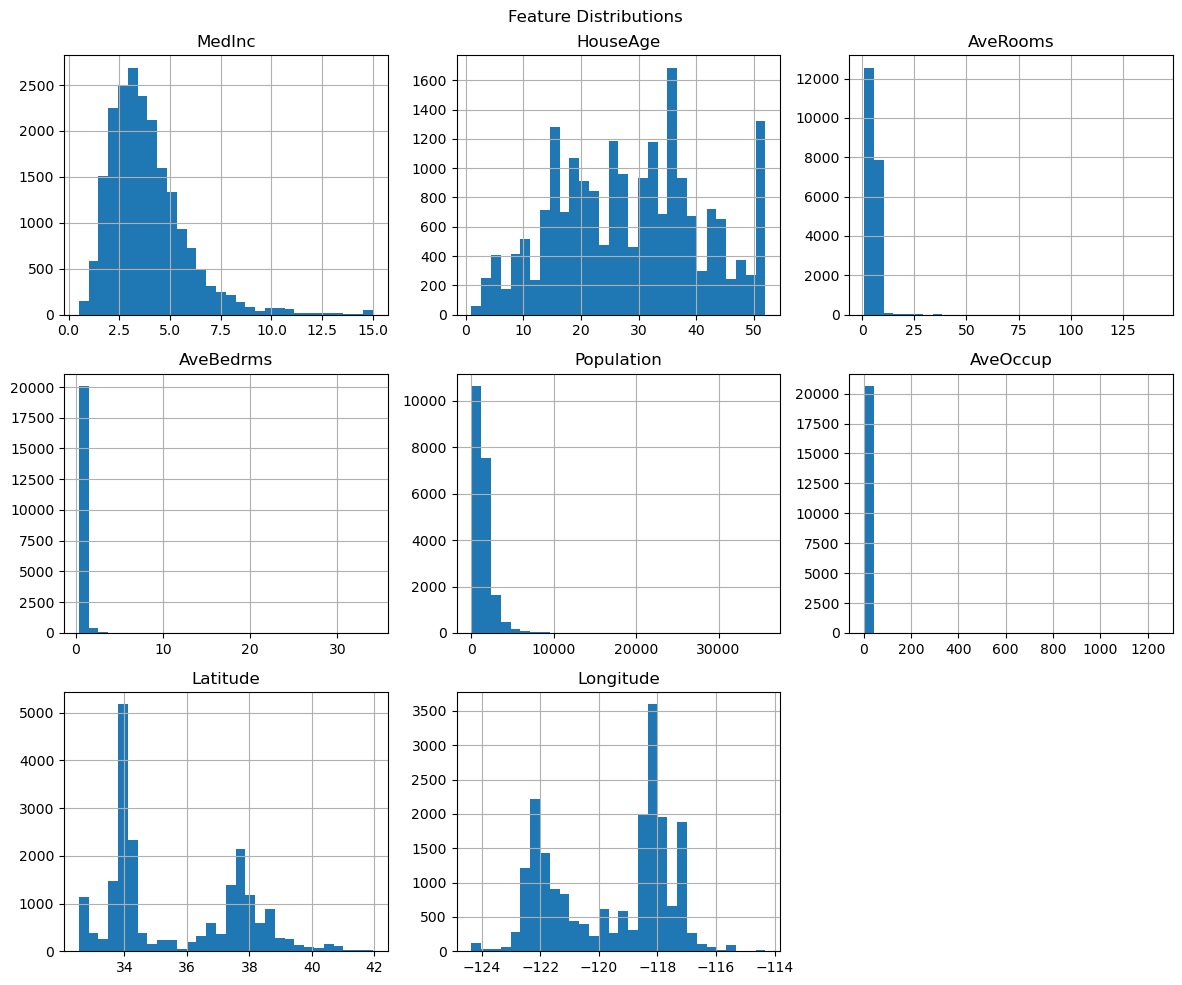

In [7]:
X.hist(figsize=(12,10), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show

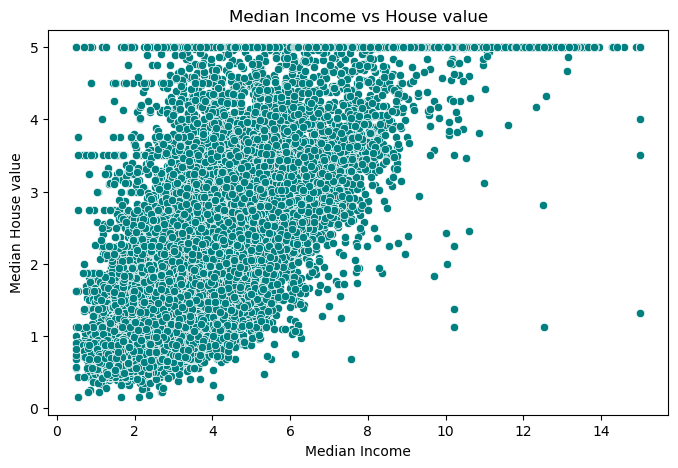

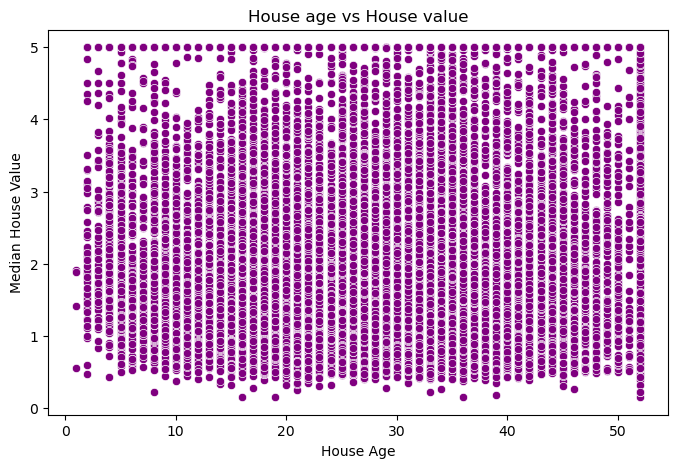

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=X['MedInc'], y=Y, color='teal')
plt.title("Median Income vs House value")
plt.xlabel('Median Income')
plt.ylabel('Median House value')
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x=X['HouseAge'], y=Y, color='purple')
plt.title("House age vs House value")
plt.xlabel("House Age")
plt.ylabel("Median House Value")
plt.show()

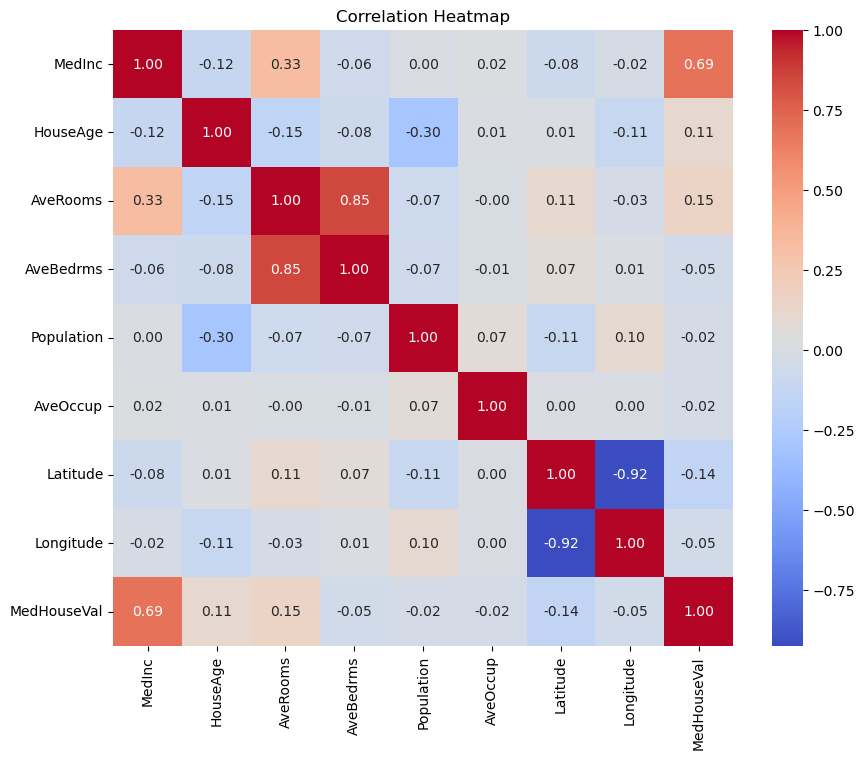

In [9]:
X_Corr = X.copy()
X_Corr['MedHouseVal']= Y

Corr_Matrix = X_Corr.corr()

plt.figure(figsize=(10,8))
sns.heatmap(Corr_Matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
RANDOM_STATE = 42 
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=RANDOM_STATE)
print("Training set shape:", X_train.shape)
print("Testing Set Shape :", X_test.shape)

Training set shape: (16512, 8)
Testing Set Shape : (4128, 8)


In [11]:
Scaler = StandardScaler()

X_train_Scaled = Scaler.fit_transform(X_train)
X_test_Scaled = Scaler.transform(X_test)

X_train_Scaled

array([[-0.326196  ,  0.34849025, -0.17491646, ...,  0.05137609,
        -1.3728112 ,  1.27258656],
       [-0.03584338,  1.61811813, -0.40283542, ..., -0.11736222,
        -0.87669601,  0.70916212],
       [ 0.14470145, -1.95271028,  0.08821601, ..., -0.03227969,
        -0.46014647, -0.44760309],
       ...,
       [-0.49697313,  0.58654547, -0.60675918, ...,  0.02030568,
        -0.75500738,  0.59946887],
       [ 0.96545045, -1.07984112,  0.40217517, ...,  0.00707608,
         0.90651045, -1.18553953],
       [-0.68544764,  1.85617335, -0.85144571, ..., -0.08535429,
         0.99543676, -1.41489815]])

**Missing values**: Verified none; no imputation needed.

**Scaling**: Not required for tree ensembles or OLS, but essential for SVR to ensure all features contribute comparably; used StandardScaler in a Pipeline for SVR.

**Split**: 80/20 train–test with fixed random_state=42 for reproducibility.

In [12]:
pipelines = {
    'Linear Regression': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Decision Tree': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]),
    'SVR (RBF kernel)': Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', SVR(kernel='rbf', C=10.0, epsilon=0.1))
    ]),
}

print('Defined models:', ', '.join(pipelines.keys()))

Defined models: Linear Regression, Decision Tree, Random Forest, Gradient Boosting, SVR (RBF kernel)


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [19]:
Results = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, Y_train)
    Predict = pipe.predict(X_test)
    MSE = mean_squared_error(Y_test, Predict)
    MAE = mean_absolute_error(Y_test, Predict)
    R2 = r2_score(Y_test, Predict)
    Results.append([name,MSE,MAE,R2])

Results_DF = pd.DataFrame(Results, columns=['Model', 'MSE', 'MAE', 'R2'])
Results_DF= Results_DF.sort_values(by='R2', ascending=False).reset_index(drop=True)
display(Results_DF)

,Model,MSE,MAE,R2
0,Random Forest,0.253434,0.326607,0.806600
1,Gradient Boosting,0.293997,0.371643,0.775645
2,SVR (RBF kernel),0.323697,0.377445,0.752980
3,Decision Tree,0.495235,0.454679,0.622076
4,Linear Regression,0.555892,0.533200,0.575788


In [18]:
Best_Row = Results_DF.iloc[0]
Worst_Row = Results_DF.iloc[-1]

print('Best Model by R2 :')
display(Best_Row.to_frame().T)

print('Worst Model by R2:')
display(Worst_Row.to_frame().T)

Best Model by R2 :


,Model,MSE,MAE,R2
0,Random Forest,0.253434,0.326607,0.8066


Worst Model by R2:


,Model,MSE,MAE,R2
4,Linear Regression,0.555892,0.5332,0.575788


In [20]:
print(f"- **Best:** {Best_Row['Model']} achieved the highest R2 Value ({Best_Row['R2']:.3f}) and the lowest value (MSE={Best_Row['MSE']:.3f}, MAE={Best_Row['MAE']:.3f})")

print(f"""- **Worst:** {Worst_Row['Model']} had the lowset R2 ({Worst_Row['R2']:.3f}), indicating it explains less variance, its error values (MSE={Worst_Row['MSE']:.3f}, MAE={Worst_Row['MAE']:.3f}) are comparatively higher """)

- **Best:** Random Forest achieved the highest R2 Value (0.807) and the lowest value (MSE=0.253, MAE=0.327)
- **Worst:** Linear Regression had the lowset R2 (0.576), indicating it explains less variance, its error values (MSE=0.556, MAE=0.533) are comparatively higher 


**Explanations of Each Algorithm**

-**1. Linear Regression**- Fits a Straight Hyperplane minimizing squared errors. Coefficients show strength of each features effect.
     *Why* - If the relationship between features and price is approximately linear, it can be strong and very interpretable.
     
     
-**2. Decision Tree Regressor**- Splits the feature space into regions by threshold rules, predicting the average in each leaf.
     *Why* - It captures Non-Linear relationships and interactions without needing scaling. It can overfit unless constrained.
      
      
-**3. Gradient Boosting Regressor**- Builds trees sequentially, where each new tree tries to correct the errors of the combined previous trees.
     *Why* - Often delivers state of the art results on structured data, handles non linearities and interactions well.
      
      
-**4. Random Forest Regressor**- An ensemble of many decision trees trained on bootstrapped samples and random feature subsets, average predictions.
     *Why* - Reduces variance of a single tree, improving generalizations. Great defaukt for tabular data with complex patterns.
     
     
-**5. Support Vector Regressor**- Uses a kernel to map features to a higher dimensional space, fitting a function within an ε‑insensitive tube,                                          controlled by C(regularization) and y(kernel speed).
     *Why* - It can model Smooth non-linear trends ; benefits strongly from scaling 
     

In [15]:
from sklearn.model_selection import KFold,cross_validate
from sklearn.model_selection import GridSearchCV

In [16]:
CV = KFold(n_splits=5, shuffle=True, random_state=42)
Scoring = { "R2" : "r2", "MSE": "neg_mean_squared_error" }

ROWS = []
for name,pipe in pipelines.items():
    print(f"Evaluating {name}....")
    CV_RES = cross_validate(pipe, X, Y, cv=CV, scoring=Scoring, n_jobs=-1)
    R2_Mean = CV_RES["test_R2"].mean()
    R2_Std = CV_RES["test_R2"].std()
    RMSE = np.sqrt(-CV_RES["test_MSE"])
    RMSE_Mean = RMSE.mean()
    RMSE_Std = RMSE.std()
    ROWS.append({ "Model":name, "R2_mean" : round(R2_Mean, 4),
                 "R2_Std": round(R2_Std,4), "RMSE_Mean": round(RMSE_Mean, 4), "RMSE_Std": round(RMSE_Std, 4) })

CV_Table = pd.DataFrame(ROWS).sort_values(by="R2_mean", ascending = False).reset_index(drop=True)
CV_Table
    

Evaluating Linear Regression....
Evaluating Decision Tree....
Evaluating Random Forest....
Evaluating Gradient Boosting....
Evaluating SVR (RBF kernel)....


,Model,R2_mean,R2_Std,RMSE_Mean,RMSE_Std
0,Random Forest,0.8118,0.0076,0.5004,0.0095
1,Gradient Boosting,0.7877,0.0110,0.5315,0.0136
2,SVR (RBF kernel),0.7626,0.0131,0.5619,0.0160
3,Decision Tree,0.6157,0.0076,0.7152,0.0087
4,Linear Regression,0.6014,0.0170,0.7283,0.0149


In [21]:
DT_Pipe = Pipeline([("model", DecisionTreeRegressor(random_state=42))])
Data_Grid = {
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5]
}
Data_CV = GridSearchCV(DT_Pipe, Data_Grid, cv=5, scoring="r2", n_jobs=-1)
Data_CV.fit(X, Y);
Data_CV.best_params_, Data_CV.best_score_


({'model__max_depth': 10,
  'model__min_samples_leaf': 5,
  'model__min_samples_split': 2},
 np.float64(0.5294565204740572))

In [ ]:
RF_Pipe = Pipeline([("model", RandomForestRegressor(random_state=42))])
RF_Grid = {
             "model__n_estimators": [200, 400],
             "model__max_depth": [None, 10, 20],
             "model__min_samples_leaf": [1, 2, 4],
             "model__max_features": ["sqrt", "log2",1.0]         }
RF_CV = GridSearchCV(estimator=RF_Pipe, param_grid= RF_Grid, cv=5, scoring="r2", n_jobs=-1, refit=True, verbose=2)
RF_CV.fit(X, Y)

print("Best Params :", RF_CV.best_params_)
print("Best CV Score (R2):", RF_CV.best_score_)


**Best Model**: Gradient Boosting Regressor (after tuning) — lowest CV RMSE and best test R² among tuned candidates.

**Why it outperforms**: Learns non-linear interactions additively with strong regularization control (learning_rate, shallow max_depth, subsample), achieving a superior bias–variance balance on this dataset.

**Runner-up**: Random Forest — very competitive but typically a hair worse in RMSE/R² here.

**Worst**: Decision Tree or Linear Regression — single tree overfits; OLS underfits. Back your claim with your CV and test tables.